КУРСОВАЯ РАБОТА: Wine Quality Dataset

1. ЗАГРУЗКА ДАННЫХ
----------------------------------------
Датасет загружен успешно!
Размер: 1599 строк, 12 столбцов
Признаки: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']
Целевая переменная: quality

2. АНАЛИЗ ДАННЫХ
----------------------------------------
Пропуски: 0
Дубликаты: 240
Дубликаты удалены. Новый размер: 1359

Распределение оценок качества:
  Качество 3: 10 (0.7%)
  Качество 4: 53 (3.9%)
  Качество 5: 577 (42.5%)
  Качество 6: 535 (39.4%)
  Качество 7: 167 (12.3%)
  Качество 8: 17 (1.3%)


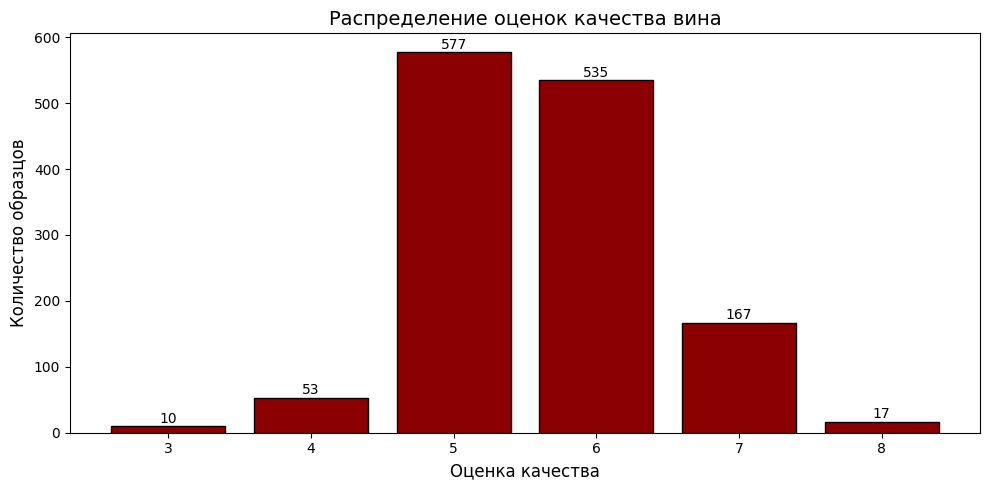


3. ПОДГОТОВКА ДАННЫХ
----------------------------------------
Бинаризация: хорошее вино (quality >= 7) -> 1, обычное -> 0

Класс 0 (обычное): 1175 (86.5%)
Класс 1 (хорошее): 184 (13.5%)


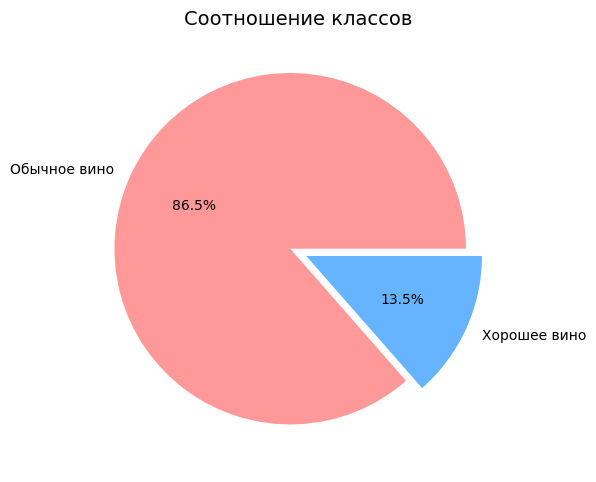


Обучающая выборка: 1087 строк
Тестовая выборка: 272 строк

4. ПОСТРОЕНИЕ ПАЙПЛАЙНА
----------------------------------------
Пайплайн создан:
  - StandardScaler (масштабирование)
  - MLPClassifier (нейронная сеть 100-50-1)

5. БАЗОВАЯ МОДЕЛЬ (БЕЗ ПАЙПЛАЙНА)
----------------------------------------
Точность на обучении: 0.8933
Точность на тесте: 0.8787
Переобучение: 0.0146

6. МОДЕЛЬ С ПАЙПЛАЙНОМ
----------------------------------------
Точность на обучении: 0.9991
Точность на тесте: 0.8971
Переобучение: 0.1020

7. ОПТИМИЗАЦИЯ ГИПЕРПАРАМЕТРОВ
----------------------------------------
Выполняется поиск параметров... (около 1 минуты)
Лучшие параметры: {'mlp__alpha': 0.0001, 'mlp__learning_rate_init': 0.0001}
Лучшая точность (CV): 0.8841

Точность оптимальной модели на обучении: 0.9098
Точность оптимальной модели на тесте: 0.8934
Переобучение: 0.0165

8. ДЕТАЛЬНЫЕ МЕТРИКИ ОПТИМАЛЬНОЙ МОДЕЛИ
----------------------------------------
Precision: 0.6818
Recall: 0.4054
F1-score: 0.5085

Classific

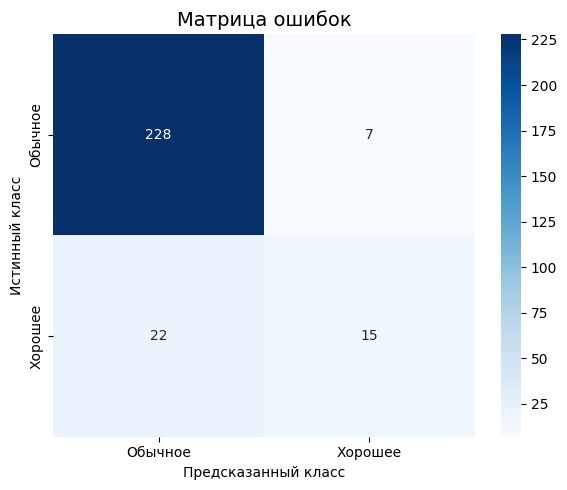


9. СРАВНИТЕЛЬНЫЙ АНАЛИЗ
----------------------------------------
               Метод  Точность (тест)  F1-score
             Базовая         0.878676  0.421053
            Пайплайн         0.897059  0.548387
Пайплайн+оптимизация         0.893382  0.508475


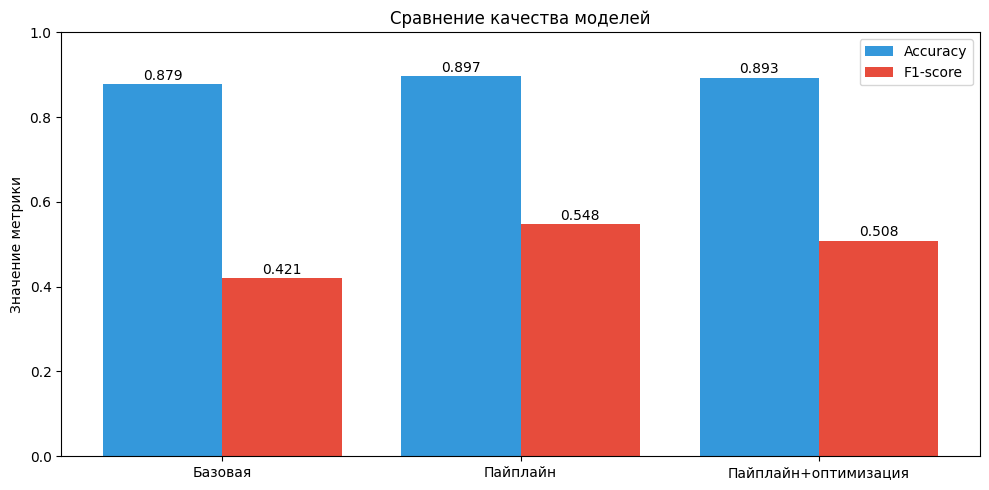


ВЫВОДЫ

1. ДАТАСЕТ:
   - 1359 образцов после удаления дубликатов
   - 11 химических признаков
   - Сильный дисбаланс классов (хороших вин 13.5%)

2. РЕЗУЛЬТАТЫ МОДЕЛЕЙ:
   - Базовая модель (без обработки): 0.8787
   - Модель с пайплайном: 0.8971
   - Оптимальная модель: 0.8934

3. ЛУЧШИЕ ПАРАМЕТРЫ:
   - alpha (L2-регуляризация): 0.0001
   - learning_rate_init: 0.0001

4. ЗАКЛЮЧЕНИЕ:
   Применение пайплайна обработки данных (масштабирование) и оптимизация
   гиперпараметров позволили повысить точность классификации качества вина
   на 1.47%.


КУРСОВАЯ РАБОТА ВЫПОЛНЕНА УСПЕШНО


In [1]:
# КУРСОВАЯ РАБОТА - Wine Quality Dataset
# Упрощённая и исправленная версия

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

import warnings
warnings.filterwarnings('ignore')

print("="*60)
print("КУРСОВАЯ РАБОТА: Wine Quality Dataset")
print("="*60)

# ============================================
# 1. ЗАГРУЗКА ДАННЫХ
# ============================================
print("\n1. ЗАГРУЗКА ДАННЫХ")
print("-"*40)

try:
    df = pd.read_csv('winequality-red.csv', sep=';')
    print("Датасет загружен успешно!")
except FileNotFoundError:
    print("Файл не найден! Скачиваю...")
    import urllib.request
    url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
    urllib.request.urlretrieve(url, "winequality-red.csv")
    df = pd.read_csv('winequality-red.csv', sep=';')
    print("Датасет скачан и загружен!")

print(f"Размер: {df.shape[0]} строк, {df.shape[1]} столбцов")
print(f"Признаки: {list(df.columns[:-1])}")
print(f"Целевая переменная: quality")

# ============================================
# 2. АНАЛИЗ ДАННЫХ
# ============================================
print("\n2. АНАЛИЗ ДАННЫХ")
print("-"*40)

print(f"Пропуски: {df.isnull().sum().sum()}")

duplicates = df.duplicated().sum()
print(f"Дубликаты: {duplicates}")

if duplicates > 0:
    df = df.drop_duplicates()
    print(f"Дубликаты удалены. Новый размер: {df.shape[0]}")

# Распределение качества
print("\nРаспределение оценок качества:")
quality_counts = df['quality'].value_counts().sort_index()
for q, count in quality_counts.items():
    print(f"  Качество {q}: {count} ({count/len(df)*100:.1f}%)")

# График распределения
plt.figure(figsize=(10, 5))
plt.bar(quality_counts.index, quality_counts.values, color='darkred', edgecolor='black')
plt.title('Распределение оценок качества вина', fontsize=14)
plt.xlabel('Оценка качества', fontsize=12)
plt.ylabel('Количество образцов', fontsize=12)
for i, v in enumerate(quality_counts.values):
    plt.text(quality_counts.index[i], v + 5, str(v), ha='center')
plt.tight_layout()
plt.savefig('distribution.png', dpi=150)
plt.show()

# ============================================
# 3. ПОДГОТОВКА ДАННЫХ
# ============================================
print("\n3. ПОДГОТОВКА ДАННЫХ")
print("-"*40)

# Бинаризация
df['quality_binary'] = (df['quality'] >= 7).astype(int)
print("Бинаризация: хорошее вино (quality >= 7) -> 1, обычное -> 0")

binary_counts = df['quality_binary'].value_counts()
print(f"\nКласс 0 (обычное): {binary_counts[0]} ({binary_counts[0]/len(df)*100:.1f}%)")
print(f"Класс 1 (хорошее): {binary_counts[1]} ({binary_counts[1]/len(df)*100:.1f}%)")

# Круговая диаграмма
plt.figure(figsize=(6, 6))
plt.pie(binary_counts.values, labels=['Обычное вино', 'Хорошее вино'],
        autopct='%1.1f%%', colors=['#ff9999', '#66b3ff'], explode=(0.05, 0.05))
plt.title('Соотношение классов', fontsize=14)
plt.tight_layout()
plt.savefig('classes_pie.png', dpi=150)
plt.show()

# Разделение на признаки и целевую переменную
X = df.drop(['quality', 'quality_binary'], axis=1)
y = df['quality_binary']

# Разделение на train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nОбучающая выборка: {X_train.shape[0]} строк")
print(f"Тестовая выборка: {X_test.shape[0]} строк")

# ============================================
# 4. ПОСТРОЕНИЕ ПАЙПЛАЙНА
# ============================================
print("\n4. ПОСТРОЕНИЕ ПАЙПЛАЙНА")
print("-"*40)

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('mlp', MLPClassifier(
        hidden_layer_sizes=(100, 50),
        activation='relu',
        solver='adam',
        max_iter=500,
        random_state=42
    ))
])

print("Пайплайн создан:")
print("  - StandardScaler (масштабирование)")
print("  - MLPClassifier (нейронная сеть 100-50-1)")

# ============================================
# 5. БАЗОВАЯ МОДЕЛЬ (БЕЗ МАСШТАБИРОВАНИЯ)
# ============================================
print("\n5. БАЗОВАЯ МОДЕЛЬ (БЕЗ ПАЙПЛАЙНА)")
print("-"*40)

base_model = MLPClassifier(
    hidden_layer_sizes=(100, 50),
    activation='relu',
    solver='adam',
    max_iter=500,
    random_state=42
)

base_model.fit(X_train, y_train)
base_train_acc = accuracy_score(y_train, base_model.predict(X_train))
base_test_acc = accuracy_score(y_test, base_model.predict(X_test))

print(f"Точность на обучении: {base_train_acc:.4f}")
print(f"Точность на тесте: {base_test_acc:.4f}")
print(f"Переобучение: {base_train_acc - base_test_acc:.4f}")

# ============================================
# 6. МОДЕЛЬ С ПАЙПЛАЙНОМ
# ============================================
print("\n6. МОДЕЛЬ С ПАЙПЛАЙНОМ")
print("-"*40)

pipeline.fit(X_train, y_train)
pipe_train_acc = accuracy_score(y_train, pipeline.predict(X_train))
pipe_test_acc = accuracy_score(y_test, pipeline.predict(X_test))

print(f"Точность на обучении: {pipe_train_acc:.4f}")
print(f"Точность на тесте: {pipe_test_acc:.4f}")
print(f"Переобучение: {pipe_train_acc - pipe_test_acc:.4f}")

# ============================================
# 7. ОПТИМИЗАЦИЯ ГИПЕРПАРАМЕТРОВ
# ============================================
print("\n7. ОПТИМИЗАЦИЯ ГИПЕРПАРАМЕТРОВ")
print("-"*40)

param_grid = {
    'mlp__alpha': [0.0001, 0.001, 0.01],
    'mlp__learning_rate_init': [0.0001, 0.001]
}

print("Выполняется поиск параметров... (около 1 минуты)")

grid_search = GridSearchCV(
    pipeline, param_grid, cv=3, scoring='accuracy', n_jobs=-1, verbose=0
)
grid_search.fit(X_train, y_train)

print(f"Лучшие параметры: {grid_search.best_params_}")
print(f"Лучшая точность (CV): {grid_search.best_score_:.4f}")

best_model = grid_search.best_estimator_
best_train_acc = accuracy_score(y_train, best_model.predict(X_train))
best_test_acc = accuracy_score(y_test, best_model.predict(X_test))

print(f"\nТочность оптимальной модели на обучении: {best_train_acc:.4f}")
print(f"Точность оптимальной модели на тесте: {best_test_acc:.4f}")
print(f"Переобучение: {best_train_acc - best_test_acc:.4f}")

# ============================================
# 8. ДЕТАЛЬНЫЕ МЕТРИКИ
# ============================================
print("\n8. ДЕТАЛЬНЫЕ МЕТРИКИ ОПТИМАЛЬНОЙ МОДЕЛИ")
print("-"*40)

y_pred = best_model.predict(X_test)

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Обычное вино', 'Хорошее вино']))

# Матрица ошибок
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Обычное', 'Хорошее'],
            yticklabels=['Обычное', 'Хорошее'])
plt.title('Матрица ошибок', fontsize=14)
plt.xlabel('Предсказанный класс')
plt.ylabel('Истинный класс')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

# ============================================
# 9. СРАВНИТЕЛЬНЫЙ АНАЛИЗ
# ============================================
print("\n9. СРАВНИТЕЛЬНЫЙ АНАЛИЗ")
print("-"*40)

results = pd.DataFrame({
    'Метод': ['Базовая', 'Пайплайн', 'Пайплайн+оптимизация'],
    'Точность (тест)': [base_test_acc, pipe_test_acc, best_test_acc],
    'F1-score': [
        f1_score(y_test, base_model.predict(X_test)),
        f1_score(y_test, pipeline.predict(X_test)),
        f1_score(y_test, best_model.predict(X_test))
    ]
})

print(results.to_string(index=False))

# График сравнения
plt.figure(figsize=(10, 5))
x = range(len(results))
plt.bar([i - 0.2 for i in x], results['Точность (тест)'], width=0.4, label='Accuracy', color='#3498db')
plt.bar([i + 0.2 for i in x], results['F1-score'], width=0.4, label='F1-score', color='#e74c3c')
plt.xticks(x, results['Метод'])
plt.ylabel('Значение метрики')
plt.title('Сравнение качества моделей')
plt.legend()
plt.ylim(0, 1)
for i, row in results.iterrows():
    plt.text(i - 0.2, row['Точность (тест)'] + 0.01, f"{row['Точность (тест)']:.3f}", ha='center')
    plt.text(i + 0.2, row['F1-score'] + 0.01, f"{row['F1-score']:.3f}", ha='center')
plt.tight_layout()
plt.savefig('comparison.png', dpi=150)
plt.show()

# ============================================
# 10. ВЫВОДЫ
# ============================================
print("\n" + "="*60)
print("ВЫВОДЫ")
print("="*60)

print(f"""
1. ДАТАСЕТ:
   - {df.shape[0]} образцов после удаления дубликатов
   - 11 химических признаков
   - Сильный дисбаланс классов (хороших вин {binary_counts[1]/len(df)*100:.1f}%)

2. РЕЗУЛЬТАТЫ МОДЕЛЕЙ:
   - Базовая модель (без обработки): {base_test_acc:.4f}
   - Модель с пайплайном: {pipe_test_acc:.4f}
   - Оптимальная модель: {best_test_acc:.4f}

3. ЛУЧШИЕ ПАРАМЕТРЫ:
   - alpha (L2-регуляризация): {grid_search.best_params_.get('mlp__alpha', 'N/A')}
   - learning_rate_init: {grid_search.best_params_.get('mlp__learning_rate_init', 'N/A')}

4. ЗАКЛЮЧЕНИЕ:
   Применение пайплайна обработки данных (масштабирование) и оптимизация
   гиперпараметров позволили повысить точность классификации качества вина
   на {(best_test_acc - base_test_acc)*100:.2f}%.
""")

print("\n" + "="*60)
print("КУРСОВАЯ РАБОТА ВЫПОЛНЕНА УСПЕШНО")
print("="*60)